
=== s-wave BCS scan ===
pairing=s, mu=-4.8, n=0.000000000000, doping=1.000000000000, Delta0=0.000000000000e+00, dia=0.000000000000e+00, para=0.000000000000e+00, Ds=0.000000000000e+00
pairing=s, mu=-4.752, n=0.000000000000, doping=1.000000000000, Delta0=0.000000000000e+00, dia=0.000000000000e+00, para=0.000000000000e+00, Ds=0.000000000000e+00
pairing=s, mu=-4.704, n=0.000000000000, doping=1.000000000000, Delta0=0.000000000000e+00, dia=0.000000000000e+00, para=0.000000000000e+00, Ds=0.000000000000e+00
pairing=s, mu=-4.656, n=0.000000000000, doping=1.000000000000, Delta0=0.000000000000e+00, dia=0.000000000000e+00, para=0.000000000000e+00, Ds=0.000000000000e+00
pairing=s, mu=-4.608, n=0.000000000000, doping=1.000000000000, Delta0=0.000000000000e+00, dia=0.000000000000e+00, para=0.000000000000e+00, Ds=0.000000000000e+00
pairing=s, mu=-4.56, n=0.000000000000, doping=1.000000000000, Delta0=0.000000000000e+00, dia=0.000000000000e+00, para=0.000000000000e+00, Ds=0.000000000000e+00
pairing=s, m

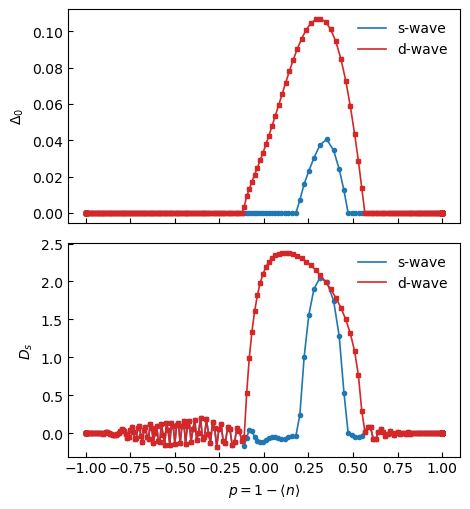


Finished in 5.68 s


In [ ]:
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize


def band_energy(kx, ky, mu, hop):
    cx = np.cos(kx)
    cy = np.cos(ky)
    t1, t2 = hop

    return (
        -2.0 * (cx + cy)
        - 4.0 * t1 * cx * cy
        - 4.0 * t2 * (cx * cx + cy * cy - 1.0)
        - mu
    )


def velocity_x(kx, ky, hop):
    t1, t2 = hop

    return (
        2.0 * np.sin(kx)
        + 4.0 * t1 * np.sin(kx) * np.cos(ky)
        + 8.0 * t2 * np.sin(kx) * np.cos(kx)
    )


def curvature_xx(kx, ky, hop):
    t1, t2 = hop

    return (
        2.0 * np.cos(kx)
        + 4.0 * t1 * np.cos(kx) * np.cos(ky)
        + 8.0 * t2 * (np.cos(kx) ** 2 - np.sin(kx) ** 2)
    )


def form_factor(kx, ky, pairing):
    if pairing == "s":
        return np.ones_like(kx, dtype=float)

    if pairing == "d":
        return np.cos(kx) - np.cos(ky)

    raise ValueError("pairing must be 's' or 'd'")


def full_bz_midpoint_mesh(grid_n):
    grid = -np.pi + (np.arange(grid_n) + 0.5) * (2.0 * np.pi / grid_n)
    kx, ky = np.meshgrid(grid, grid, indexing="ij")

    return kx.ravel(), ky.ravel()


def stable_tanh_half(beta, energy):
    return np.tanh(0.5 * beta * energy)


def stable_beta_sech2_half(beta, energy):
    x = 0.5 * beta * energy

    out = np.zeros_like(x, dtype=float)
    mask = np.abs(x) < 40.0

    c = np.cosh(x[mask])
    out[mask] = 0.5 * beta / (c * c)

    return out


def gap_residual(delta0, xi, gk, interaction, beta):
    delta_k = delta0 * gk

    energy = np.sqrt(xi * xi + delta_k * delta_k)
    energy = np.maximum(energy, 1e-14)

    kernel = gk * gk * stable_tanh_half(beta, energy) / (2.0 * energy)

    return interaction * np.mean(kernel) - 1.0


def solve_gap_delta0(
    kx,
    ky,
    mu,
    hop,
    interaction,
    beta,
    pairing,
    bracket=(1e-10, 1.0),
):
    xi = band_energy(kx, ky, mu, hop)
    gk = form_factor(kx, ky, pairing)

    lo, hi = bracket

    f_lo = gap_residual(lo, xi, gk, interaction, beta)
    f_hi = gap_residual(hi, xi, gk, interaction, beta)

    while f_lo * f_hi > 0.0 and hi < max(20.0, 8.0 * abs(interaction)):
        hi *= 2.0
        f_hi = gap_residual(hi, xi, gk, interaction, beta)

    if f_lo * f_hi > 0.0:
        return 0.0

    sol = optimize.root_scalar(
        lambda d: gap_residual(d, xi, gk, interaction, beta),
        bracket=(lo, hi),
        xtol=1e-12,
        rtol=1e-12,
    )

    return sol.root if sol.converged else 0.0


def bcs_observables_at_delta(kx, ky, mu, hop, beta, pairing, delta0):
    xi = band_energy(kx, ky, mu, hop)
    vx = velocity_x(kx, ky, hop)
    kxx = curvature_xx(kx, ky, hop)
    gk = form_factor(kx, ky, pairing)

    delta_k = delta0 * gk

    energy = np.sqrt(xi * xi + delta_k * delta_k)
    energy = np.maximum(energy, 1e-14)

    tanh_half = stable_tanh_half(beta, energy)

    n_k = 1.0 - xi / energy * tanh_half
    filling = np.mean(n_k)

    dia_integrand = kxx * n_k

    para_integrand = vx * vx * stable_beta_sech2_half(beta, energy)
    para_integrand *= (xi * xi) / (energy * energy)

    dia = np.pi * np.mean(dia_integrand)
    para = np.pi * np.mean(para_integrand)
    stiffness = dia - para

    return filling, stiffness, dia, para


def bcs_single_mu(
    mu,
    beta,
    grid_n,
    interaction,
    pairing="s",
    hop=np.array([0.0, 0.0]),
    fixed_delta0=None,
):
    kx, ky = full_bz_midpoint_mesh(grid_n)

    if fixed_delta0 is None:
        delta0 = solve_gap_delta0(
            kx=kx,
            ky=ky,
            mu=mu,
            hop=hop,
            interaction=interaction,
            beta=beta,
            pairing=pairing,
            bracket=(1e-10, max(abs(interaction), 1e-4)),
        )
    else:
        delta0 = float(fixed_delta0)

    filling, stiffness, dia, para = bcs_observables_at_delta(
        kx=kx,
        ky=ky,
        mu=mu,
        hop=hop,
        beta=beta,
        pairing=pairing,
        delta0=delta0,
    )

    print(
        f"pairing={pairing}, mu={mu:.8g}, n={filling:.12f}, "
        f"doping={1.0 - filling:.12f}, Delta0={delta0:.12e}, "
        f"dia={dia:.12e}, para={para:.12e}, Ds={stiffness:.12e}"
    )

    return filling, stiffness, delta0, dia, para


def bcs_gap_mu_scan(
    mu_values,
    beta,
    grid_n,
    interaction,
    pairing="s",
    hop=np.array([0.0, 0.0]),
):
    fillings = []
    dopings = []
    stiffnesses = []
    gaps = []
    dias = []
    paras = []

    for mu in mu_values:
        filling, stiffness, delta0, dia, para = bcs_single_mu(
            mu=mu,
            beta=beta,
            grid_n=grid_n,
            interaction=interaction,
            pairing=pairing,
            hop=hop,
        )

        fillings.append(filling)
        dopings.append(1.0 - filling)
        stiffnesses.append(stiffness)
        gaps.append(delta0)
        dias.append(dia)
        paras.append(para)

    return {
        "mu": np.array(mu_values, dtype=float),
        "filling": np.array(fillings, dtype=float),
        "doping": np.array(dopings, dtype=float),
        "gap": np.array(gaps, dtype=float),
        "stiffness": np.array(stiffnesses, dtype=float),
        "diamagnetic": np.array(dias, dtype=float),
        "paramagnetic": np.array(paras, dtype=float),
        "beta": beta,
        "grid_n": grid_n,
        "interaction": interaction,
        "pairing": pairing,
        "hop": np.array(hop, dtype=float),
    }


def plot_gap_and_stiffness(data_s, data_d=None, filename=None):
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(4.8, 5.2),
        sharex=True,
    )

    ax_gap = axes[0]
    ax_stiffness = axes[1]

    for data, label, color, marker in [
        (data_s, "s-wave", "C0", "o"),
        (data_d, "d-wave", "C3", "s"),
    ]:
        if data is None:
            continue

        order = np.argsort(data["doping"])

        x = data["doping"][order]
        gap = data["gap"][order]
        stiffness = data["stiffness"][order]

        ax_gap.plot(
            x,
            gap,
            "-",
            color=color,
            linewidth=1.2,
            label=label,
        )
        ax_gap.plot(
            x,
            gap,
            marker,
            color=color,
            markersize=3.0,
            linestyle="None",
        )

        ax_stiffness.plot(
            x,
            stiffness,
            "-",
            color=color,
            linewidth=1.2,
            label=label,
        )
        ax_stiffness.plot(
            x,
            stiffness,
            marker,
            color=color,
            markersize=3.0,
            linestyle="None",
        )

    ax_gap.set_ylabel(r"$\Delta_0$")
    ax_stiffness.set_xlabel(r"$p=1-\langle n\rangle$")
    ax_stiffness.set_ylabel(r"$D_s$")

    ax_gap.legend(frameon=False)
    ax_stiffness.legend(frameon=False)

    ax_gap.tick_params(direction="in")
    ax_stiffness.tick_params(direction="in")

    fig.tight_layout()

    if filename is not None:
        fig.savefig(filename, bbox_inches="tight")

    plt.show()


# -------------------------- run --------------------------
beta = 100
grid_n = 256

hop = np.array([-0.2, 0.1])
# hop = np.array([0.0, 0.0])
interaction = 0.8

mu_values = np.linspace(-4.8, 4.8, 201)

start = time.time()

print("\n=== s-wave BCS scan ===")
data_s = bcs_gap_mu_scan(
    mu_values=mu_values,
    beta=beta,
    grid_n=grid_n,
    interaction=interaction,
    pairing="s",
    hop=hop,
)

print("\n=== d-wave BCS scan ===")
data_d = bcs_gap_mu_scan(
    mu_values=mu_values,
    beta=beta,
    grid_n=grid_n,
    interaction=interaction,
    pairing="d",
    hop=hop,
)

plot_gap_and_stiffness(
    data_s,
    data_d,
    filename="bcs_gap_stiffness.png",
)

print(f"\nFinished in {time.time() - start:.2f} s")